11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 50s 115ms/step - accuracy: 0.9217 - loss: 0.2599 - val_accuracy: 0.9847 - val_loss: 0.0531
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9782 - loss: 0.0714 - val_accuracy: 0.9890 - val_loss: 0.0412
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9844 - loss: 0.0506 - val_accuracy: 0.9887 - val_loss: 0.0386
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9869 - loss: 0.0409 - val_accuracy: 0.9912 - val_loss: 0.0379
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9895 - loss: 0.0325 - val_accuracy: 0.9920 - val_loss: 0.0311
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9913 - loss: 0.0269
Test accuracy: 99.13%
Recognized digit: 7
Actual digit: 7


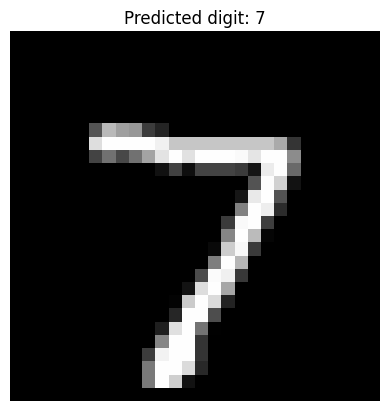

Model saved successfully!


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = (
    tf.keras.datasets.mnist.load_data()
)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(
        32, kernel_size=3, activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Conv2D(
        64, kernel_size=3, activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {accuracy * 100:.2f}%")
index = 0
image = x_test[index]
prediction = model.predict(image[np.newaxis, ...], verbose=0)
digit = np.argmax(prediction[0])
print("Recognized digit:", digit)
print("Actual digit:", y_test[index])
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Predicted digit: {digit}")
plt.axis("off")
plt.show()
model.save("handwritten_model.keras")
print("Model saved successfully!")